In [21]:
# --- 0. Setup and Imports ---
import geopandas as gpd
import pandas as pd
import numpy as np
import os
# import sys # Needed to add src directory to path

# --- Define Base Directory ---
BASE_DIR = os.path.abspath('../..') # Gets the current directory of the notebook
print(f"Base Directory: {BASE_DIR}")

Base Directory: c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors


In [2]:
# --- Define Subdirectories ---
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "Results")

In [3]:
# Import your custom GIS functions
import gis_utils as gu

In [4]:
# # --- Define Input File Paths ---
# BOUNDARIES_PATH = os.path.join(DATA_DIR, "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
# SWISSTLM_PATH = os.path.join(DATA_DIR, "SWISSTLM3D_2025.gpkg") # Verify filename
# CORINE_PATH = os.path.join(DATA_DIR, "U2018_CLC2018_V2020_20u1.gpkg") # Verify filename
# CORINE_LEGEND_PATH = os.path.join(DATA_DIR, "Info", "Legend", "Vector", "CLC_legend.csv") # Verify path
# COST_CSV_PATH = os.path.join(DATA_DIR, "resistance_costs.csv")

In [5]:
BOUNDARIES_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data", "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
SWISSTLM_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data", "SWISSTLM3D_2025.gpkg")
CORINE_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data\\Results", "U2018_CLC2018_V2020_20u1.gpkg")
CORINE_LEGEND_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data\\Results\\Info\\Legend\\Vector", "CLC_legend.csv")
COST_CSV_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\PA2-Modelling_Wildlife_Corridors\\data", "resistance_costs.csv")

In [6]:
# --- Define Output File Paths ---
# Intermediate Type Rasters
LANDCOVER_SWISSTLM_RASTER = os.path.join(RESULTS_DIR, "temp_swisstlm_lc_resist.tif")
LANDCOVER_CORINE_RASTER = os.path.join(RESULTS_DIR, "temp_corine_lc_resist.tif")
HARMONIZED_TYPE_RASTER = os.path.join(RESULTS_DIR, "harmonized_landcover_type.tif")
# Barrier Rasters
WATER_BARRIER_RASTER = os.path.join(RESULTS_DIR, "temp_water_barrier.tif")
ROAD_BARRIER_RASTER = os.path.join(RESULTS_DIR, "temp_road_barrier.tif")
# Final Output
FINAL_RASTER = os.path.join(RESULTS_DIR, "final_resistance_surface.tif")

In [7]:
# --- Define Workflow Settings ---
TARGET_CANTON = "Schaffhausen"
BUFFER_M = 10000
TARGET_RESOLUTION_M = 10.0
MAX_BARRIER_COST = 1000 # For plotting normalization

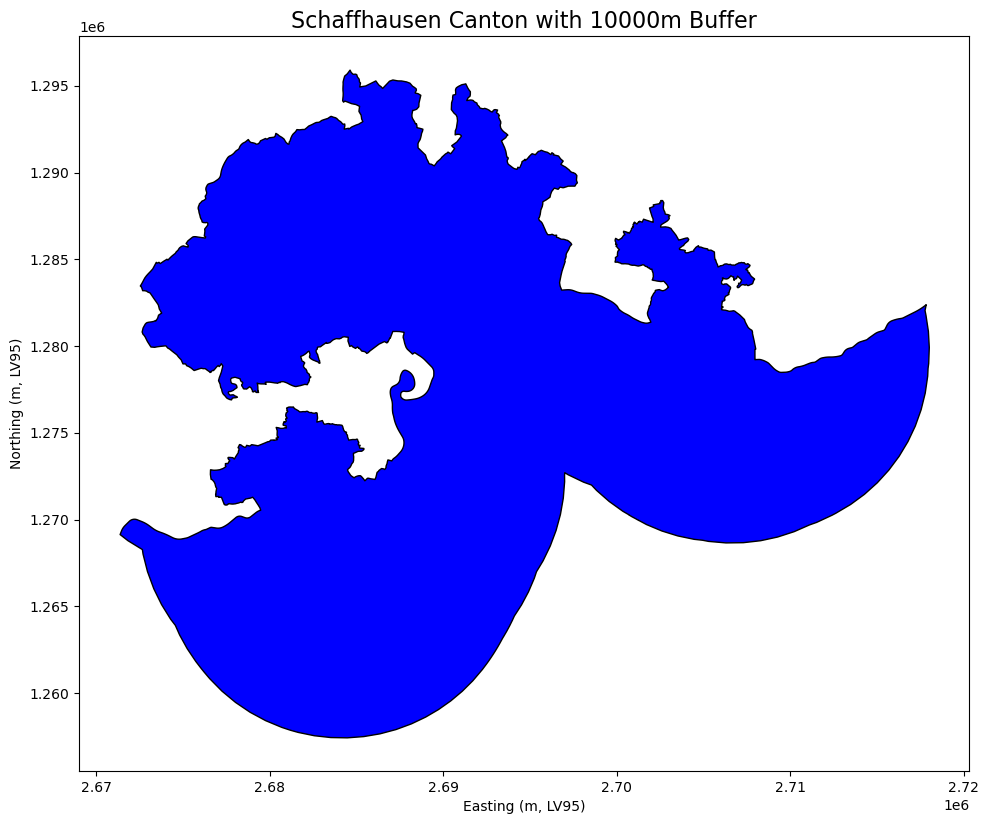

In [8]:
# --- Define Canton and bounding box ---
sh, sh_bbox = gu.filter_canton(TARGET_CANTON, BOUNDARIES_PATH, buffer_m=BUFFER_M)
target_crs = sh.crs
gu.plot_vector_layer(sh, f"{TARGET_CANTON} Canton with {BUFFER_M}m Buffer")

In [9]:
# --- Load and Prepare Vector Layers ---
# Load Landcover Layers
landcover_sh_raw = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_bb_bodenbedeckung", sh, sh_bbox)
# Filter water out of landcover layer
landcover_sh = landcover_sh_raw[~landcover_sh_raw['objektart'].isin(['Fliessgewaesser', 'Stehende Gewaesser'])].copy()

# Load Corine + Legend
landcover_clc_raw = gpd.read_file(CORINE_PATH, layer="U2018_CLC2018_V2020_20u1", engine="pyogrio")
clc_legend = pd.read_csv(CORINE_LEGEND_PATH, sep=';')
landcover_clc_raw['Code_18'] = landcover_clc_raw['Code_18'].astype(int)
landcover_clc_with_labels = landcover_clc_raw.merge(clc_legend[['CLC_CODE', 'LABEL3']], left_on='Code_18', right_on='CLC_CODE', how='left')
if landcover_clc_with_labels.crs != target_crs: landcover_clc_with_labels = landcover_clc_with_labels.to_crs(target_crs)
landcover_sh_clc_unfiltered = gpd.clip(landcover_clc_with_labels, sh) # Clip before filtering water
# Filter water out of Corine
landcover_sh_clc_clipped = landcover_sh_clc_unfiltered[~landcover_sh_clc_unfiltered['LABEL3'].isin(['Water bodies', 'Water courses'])].copy()

# Load Water & Combine
f_water_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_gewaesser_fliessgewaesser", sh, sh_bbox)
s_water_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_gewaesser_stehendes_gewaesser", sh, sh_bbox)
# water_sh_combined = gpd.GeoDataFrame(pd.concat([f_water_sh, s_water_sh], ignore_index=True), crs=target_crs)

# Load Roads
roads_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_strassen_strasse", sh, sh_bbox)


Buffering Water lines

In [10]:
# 1. Buffer the linestrings to create polygons (e.g., 5m buffer = 10m total width)
# This ensures they have a spatial footprint for rasterization at your 10m resolution
print("Buffering flowing water linestrings...")
f_water_sh_polygons = f_water_sh.copy()
f_water_sh_polygons['geometry'] = f_water_sh_polygons.geometry.buffer(5) 

print("Buffering standing water linestrings...")
s_water_sh_polygons = s_water_sh.copy()
s_water_sh_polygons['geometry'] = s_water_sh_polygons.geometry.buffer(5) 

# 2. Combine the two POLYGONAL water layers
# We use gpd.pd.concat, which is the preferred geopandas function
print("Combining water polygon layers...")
water_sh_combined = gpd.pd.concat([f_water_sh_polygons, s_water_sh_polygons], ignore_index=True)

# (Optional but recommended) Dissolve them into a single multi-polygon
# This cleans up overlaps and simplifies the geometry
water_sh_combined = water_sh_combined.dissolve()

Buffering flowing water linestrings...
Buffering standing water linestrings...
Combining water polygon layers...


Buffering road lines

In [11]:
print("Buffering road linestrings...")
roads_sh_polygons = roads_sh.copy()
roads_sh_polygons['geometry'] = roads_sh_polygons.geometry.buffer(5) 

Buffering road linestrings...


In [12]:
# --- Define Landcover Harmonization Maps ---
swisstlm_to_unified_map = {
    'Fels': 'Bare Rock/Soil',
    'Felsbloecke locker': 'Bare Rock/Soil',
    'Feuchtgebiet': 'Wetland',
    'Gebueschwald': 'Shrubland/Transitional',
    'Gehoelzflaeche': 'Shrubland/Transitional',
    'Lockergestein': 'Bare Rock/Soil',
    'Lockergestein locker': 'Bare Rock/Soil',
    'Wald': 'Forest'
}
corine_to_unified_map = {
    'Airports': 'Infrastructure/Built-up',
    'Broad-leaved forest': 'Forest',
    'Complex cultivation patterns': 'Agriculture',
    'Coniferous forest': 'Forest',
    'Continuous urban fabric': 'Urban/Built-up',
    'Discontinuous urban fabric': 'Urban/Built-up',
    'Industrial or commercial units': 'Industrial/Commercial',
    'Inland marshes': 'Wetland',
    'Land principally occupied by agriculture, with significant areas of natural vegetation': 'Agriculture',
    'Mineral extraction sites': 'Extraction/Bare',
    'Mixed forest': 'Forest',
    'Non-irrigated arable land': 'Agriculture',
    'Pastures': 'Grassland/Pasture',
    'Road and rail networks and associated land': 'Infrastructure/Built-up',
    'Sport and leisure facilities': 'Urban/Built-up',
    'Transitional woodland-shrub': 'Shrubland/Transitional',
    'Vineyards': 'Agriculture'
}

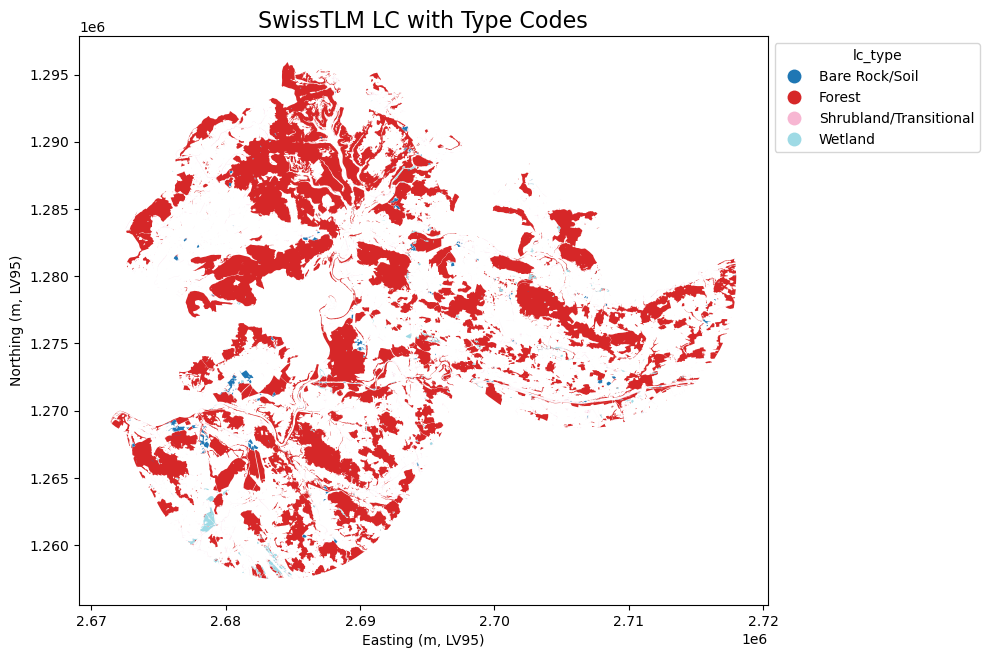

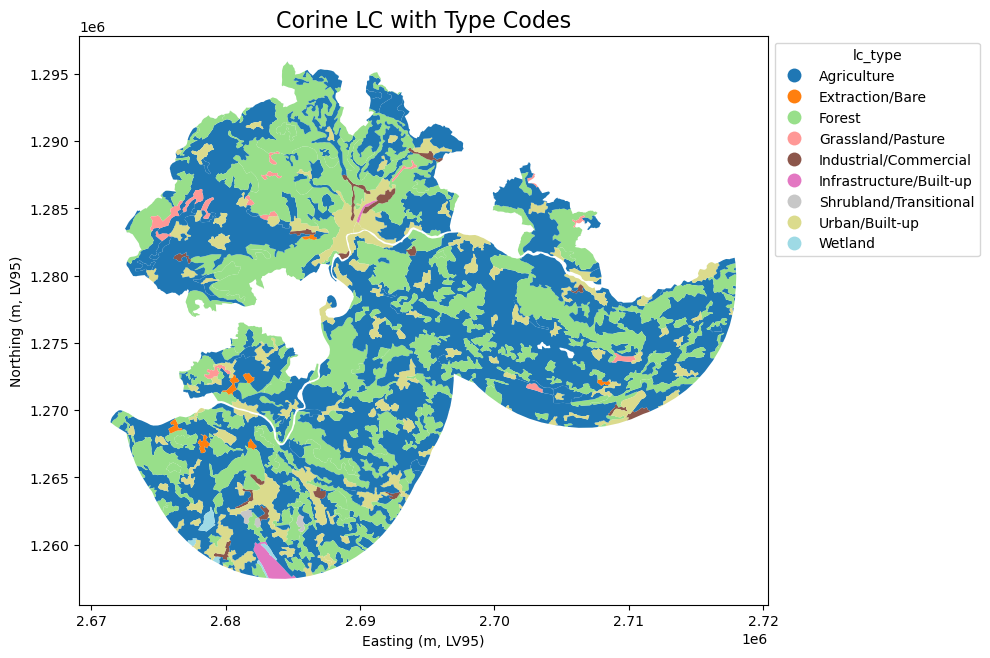

In [13]:
# --- Apply UNIFIED lc_types to Landcover Vectors ---
landcover_sh['lc_type'] = landcover_sh['objektart'].map(swisstlm_to_unified_map)
landcover_sh_clc_clipped['lc_type'] = landcover_sh_clc_clipped['LABEL3'].map(corine_to_unified_map)

# Plot vectors colored by lc_type
gu.plot_vector_layer(landcover_sh, "SwissTLM LC with Type Codes", column_to_plot='lc_type', cmap='tab20')
gu.plot_vector_layer(landcover_sh_clc_clipped, "Corine LC with Type Codes", column_to_plot='lc_type', cmap='tab20')


In [14]:
# --- Define Master Grid ---
# Define grid for rasterization and combination of the layers based on the Canton geometry
master_meta = gu.define_master_grid_meta(sh, TARGET_RESOLUTION_M, target_crs)

Master grid: 4664x3849 pixels at 10.0m resolution.


In [15]:
# --- Apply Costs and Rasterize ---
# Load resistance costs from CSV
cost_maps = gu.load_resistance_costs(COST_CSV_PATH)

landcover_sh['resistance_cost'] = landcover_sh['lc_type'].map(cost_maps.get('landcover_summary', {}))
landcover_sh_clc_clipped['resistance_cost'] = landcover_sh_clc_clipped['lc_type'].map(cost_maps.get('landcover_summary', {}))
water_sh_combined['resistance_cost'] = water_sh_combined['objektart'].map(cost_maps.get('water', {}))
roads_sh_polygons['resistance_cost'] = roads_sh_polygons['objektart'].map(cost_maps.get('roads', {}))



Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_swisstlm_lc_resist.tif
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_corine_lc_resist.tif
Plotting raster layer: Rasterized SwissTLM Types from temp_swisstlm_lc_resist.tif


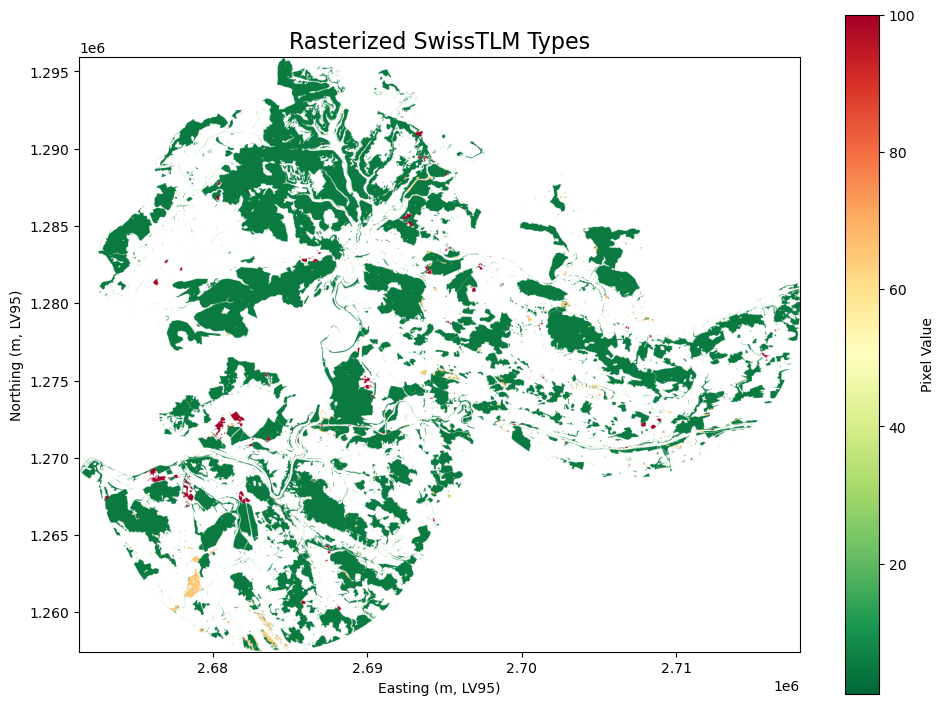

Plotting raster layer: Rasterized Corine Types from temp_corine_lc_resist.tif


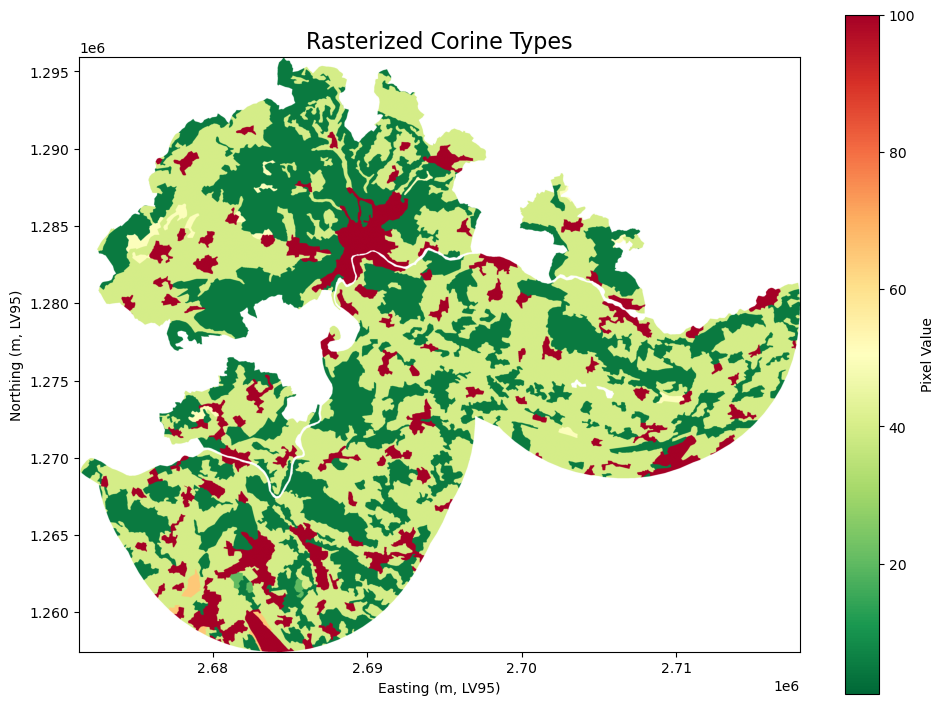

In [16]:
# --- Rasterize Landcover Layers by resistance cost ---
gu.rasterize_layer(landcover_sh, master_meta, 'resistance_cost', LANDCOVER_SWISSTLM_RASTER)
gu.rasterize_layer(landcover_sh_clc_clipped, master_meta, 'resistance_cost', LANDCOVER_CORINE_RASTER)

# Plot intermediate type rasters
gu.plot_raster_layer(LANDCOVER_SWISSTLM_RASTER, "Rasterized SwissTLM Types", cmap='RdYlGn_r', vmin=1, vmax=100)
gu.plot_raster_layer(LANDCOVER_CORINE_RASTER, "Rasterized Corine Types", cmap='RdYlGn_r', vmin=1, vmax=100)


Saved harmonized landcover COST raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\harmonized_landcover_type.tif
Plotting raster layer: Harmonized Landcover Types from harmonized_landcover_type.tif


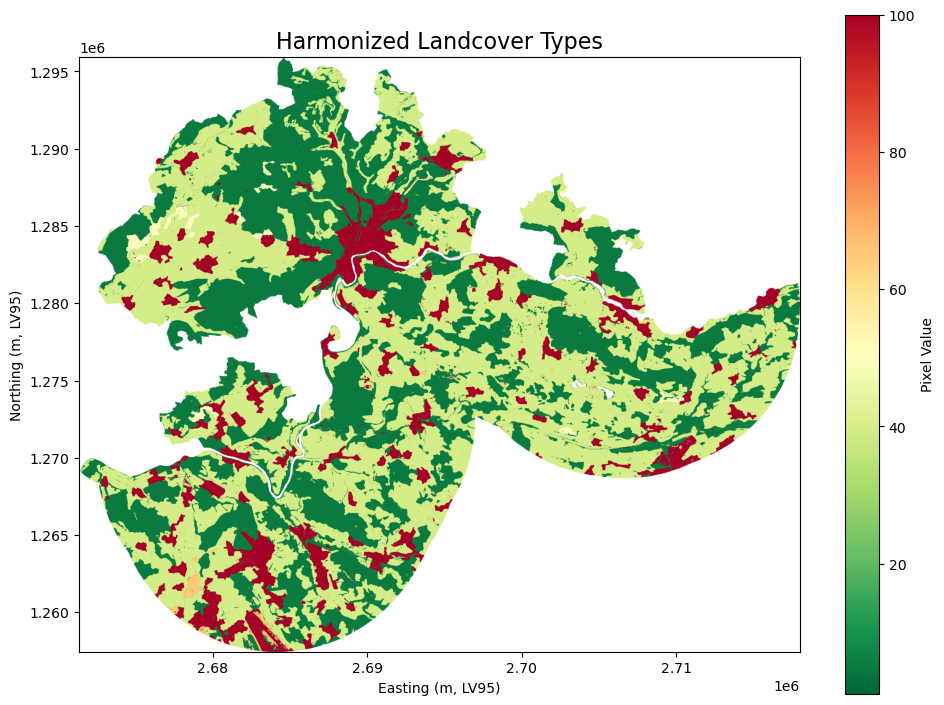

In [17]:
# --- Combine Landcover Rasters (Priority Fill) ---
gu.combine_cost_rasters_priority_fill(LANDCOVER_SWISSTLM_RASTER, LANDCOVER_CORINE_RASTER, 
                                 HARMONIZED_TYPE_RASTER)

# Plot harmonized type raster
gu.plot_raster_layer(HARMONIZED_TYPE_RASTER, "Harmonized Landcover Types", cmap='RdYlGn_r', vmin=1, vmax=100)


Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_water_barrier.tif
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_road_barrier.tif
Plotting raster layer: Rasterized Water Costs from temp_water_barrier.tif


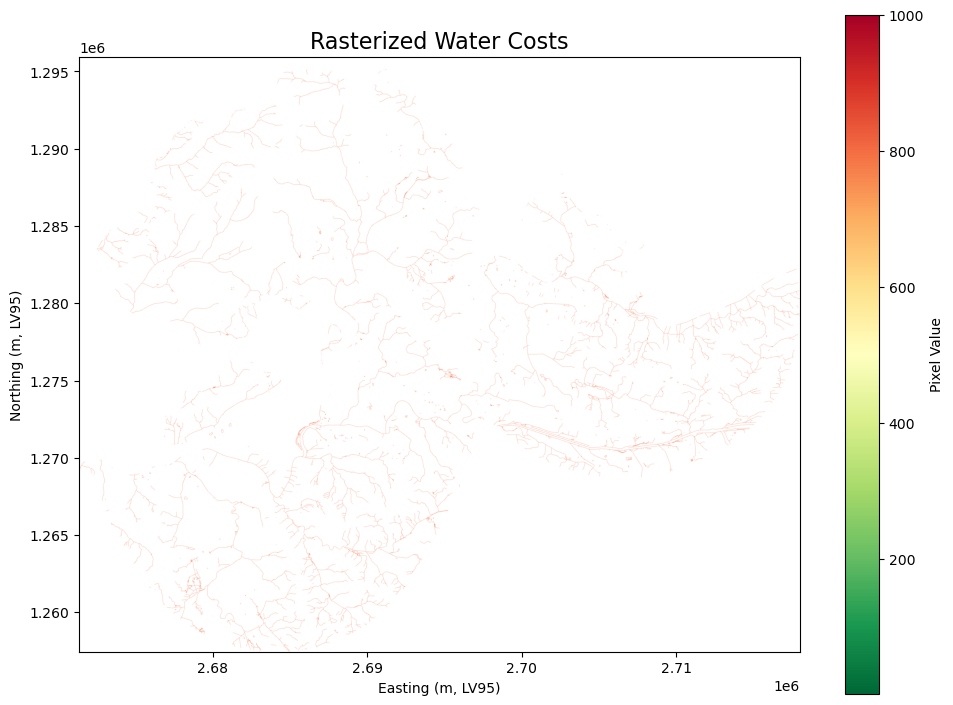

Plotting raster layer: Rasterized Road Costs from temp_road_barrier.tif


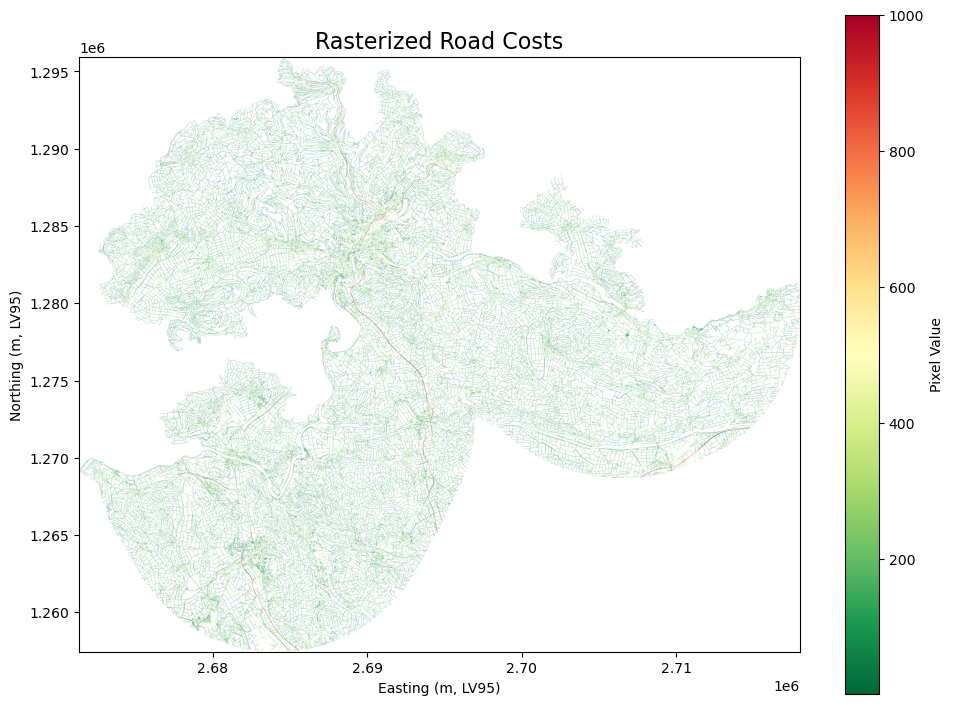

In [18]:
# Rasterize barriers using their assigned costs
gu.rasterize_layer(water_sh_combined, master_meta, 'resistance_cost', WATER_BARRIER_RASTER)
gu.rasterize_layer(roads_sh_polygons, master_meta, 'resistance_cost', ROAD_BARRIER_RASTER)

# Plot barrier rasters
gu.plot_raster_layer(WATER_BARRIER_RASTER, "Rasterized Water Costs", cmap='RdYlGn_r', vmin=1, vmax=MAX_BARRIER_COST)
gu.plot_raster_layer(ROAD_BARRIER_RASTER, "Rasterized Road Costs", cmap='RdYlGn_r', vmin=1, vmax=MAX_BARRIER_COST)


In [19]:
# --- Combine FINAL Rasters (MAX Logic) ---
input_rasters_for_final = [
    HARMONIZED_TYPE_RASTER,
    WATER_BARRIER_RASTER,
    ROAD_BARRIER_RASTER
]

valid_input_rasters = [p for p in input_rasters_for_final if os.path.exists(p)]

if valid_input_rasters:
    gu.combine_rasters_max_logic(valid_input_rasters, FINAL_RASTER)
else: print("Error: No valid intermediate rasters found to combine.")



Saved combined raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\final_resistance_surface.tif


Plotting raster layer: Final Resistance Surface (Harmonized LC + Barriers) from final_resistance_surface.tif


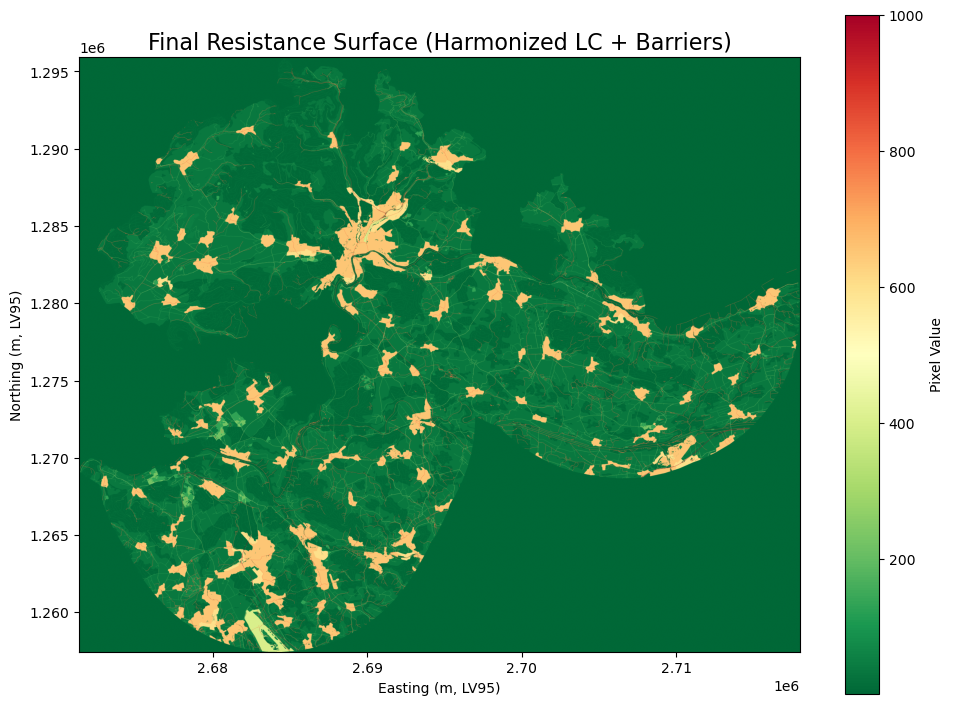

In [20]:
# --- Visualize Final Result ---

gu.plot_raster_layer(FINAL_RASTER, 
                     "Final Resistance Surface (Harmonized LC + Barriers)", 
                     cmap='RdYlGn_r', 
                     vmin=1, 
                     vmax=1000)
